# CSD Predictive Independence Ablation Study

**Do ecological indicators carry signal beyond difficulty position?**

This notebook runs a systematic 5-ablation study testing whether CSD (Critical Slowing Down) ecological indicators have genuine predictive power for boundary detection independent of difficulty-position encoding. It evaluates across multiple classifiers (LogReg/RF/SVM) and cross-validation schemes (LOPO/LOTO/LOMO) with bootstrap confidence intervals and permutation testing.

Key questions:
1. Can pure CSD features beat random chance? (Ablation 1)
2. Do dynamics (deltas/trends) add signal? (Ablation 2)
3. How strong is difficulty position alone? (Ablation 3)
4. What is each CSD feature's marginal contribution? (Ablation 4)
5. Is CSD signal robust to permutation? (Ablation 5)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All imports are pre-installed on Colab; install locally to match Colab env
# scipy==1.16.3 requires Python >=3.11; use 1.15.3 for Python 3.10 compat
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter6_csd_predictive/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  csd_features_unified: 100 examples


## Configuration

All tunable parameters are defined here. Start with minimum values for fast iteration; increase for more robust results.

In [5]:
# ── Tunable parameters ──────────────────────────────────────────────────────
# Original full values commented for reference; demo uses scaled-down values
# that still produce meaningful results within the 5-minute runtime budget.

N_BOOTSTRAP = 500         # Original: 1000
N_PERMUTATIONS = 50       # Original: 100
CLASSIFIERS = ["logreg", "rf", "svm"]    # Original: ["logreg", "rf", "svm"]
CV_SCHEMES = ["lopo", "loto", "lomo"]    # Original: ["lopo", "loto", "lomo"]
RUN_ABLATION_4 = True     # Original: True
RUN_ABLATION_5 = True     # Original: True
RF_N_ESTIMATORS = 100     # Original: 100

SEED = 42
np.random.seed(SEED)

## Feature Definitions and Data Preparation

Define the CSD ecological indicator feature groups, load the unified dataset from the demo data, and engineer derived features (difficulty-position, trend slopes).

In [6]:
# ── Feature group constants ──────────────────────────────────────────────────
RAW_CSD_FEATURES = [
    "csd_variance", "dip_statistic", "silhouette_k2",
    "bimodality_coefficient", "disagreement_rate",
]
DELTA_FEATURES = [f"{f}_delta" for f in RAW_CSD_FEATURES]
ZT_FEATURES = [f"{f}_zt" for f in RAW_CSD_FEATURES]


# ── Load unified dataset from demo data ─────────────────────────────────────
def load_unified_dataset(data: dict) -> pd.DataFrame:
    """Load the csd_features_unified dataset from loaded demo data."""
    ds = None
    for d in data.get("datasets", []):
        if d.get("dataset") == "csd_features_unified":
            ds = d
            break
    if ds is None:
        raise ValueError("csd_features_unified dataset not found")

    examples = ds["examples"]
    print(f"Found {len(examples)} examples in csd_features_unified")

    rows = []
    for ex in examples:
        row = {
            "task_family": ex["metadata_task_family"],
            "model": ex["metadata_model"],
            "difficulty_level": int(ex["metadata_difficulty_level"]),
            "d_star": int(ex["metadata_d_star"]),
            "label": 1 if ex["output"] == "near" else 0,
            "pair_key": f"{ex['metadata_task_family']}__{ex['metadata_model']}",
        }
        # Parse predict_ fields as floats
        for k, v in ex.items():
            if k.startswith("predict_") and k != "predict_label":
                fname = k[len("predict_"):]
                try:
                    row[fname] = float(v)
                except (ValueError, TypeError):
                    row[fname] = np.nan
        rows.append(row)

    df = pd.DataFrame(rows)
    print(f"DataFrame shape: {df.shape}, label distribution: near={df['label'].sum()}, safe={(1-df['label']).sum()}")
    return df


# ── Feature engineering ──────────────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create derived features needed for ablations."""
    df = df.copy()

    # Difficulty-position features
    df["difficulty_level_squared"] = df["difficulty_level"] ** 2

    # Relative position within task family's difficulty range
    for tf in df["task_family"].unique():
        mask = df["task_family"] == tf
        dmin = df.loc[mask, "difficulty_level"].min()
        dmax = df.loc[mask, "difficulty_level"].max()
        rng = dmax - dmin
        if rng > 0:
            df.loc[mask, "relative_position_in_range"] = (
                (df.loc[mask, "difficulty_level"] - dmin) / rng
            )
        else:
            df.loc[mask, "relative_position_in_range"] = 0.0

    # Trend features: rolling OLS slope over window=3 for each CSD indicator
    trend_cols = []
    for feat in RAW_CSD_FEATURES:
        col_name = f"{feat}_trend3"
        trend_cols.append(col_name)
        df[col_name] = 0.0

    for pair_key in df["pair_key"].unique():
        mask = df["pair_key"] == pair_key
        sub = df.loc[mask].sort_values("difficulty_level").copy()
        idx = sub.index
        levels = sub["difficulty_level"].values

        for feat in RAW_CSD_FEATURES:
            col_name = f"{feat}_trend3"
            vals = sub[feat].values
            slopes = np.zeros(len(vals))

            for i in range(2, len(vals)):
                x = levels[i-2:i+1].astype(float)
                y = vals[i-2:i+1]
                if np.any(np.isnan(y)):
                    slopes[i] = 0.0
                else:
                    try:
                        slopes[i] = np.polyfit(x, y, 1)[0]
                    except (np.linalg.LinAlgError, ValueError):
                        slopes[i] = 0.0

            df.loc[idx, col_name] = slopes

    print(f"Engineered features. New columns: difficulty_level_squared, relative_position_in_range, {len(trend_cols)} trend features")
    return df


# ── Load and prepare ────────────────────────────────────────────────────────
df = load_unified_dataset(data)
df = engineer_features(df)

near_proportion = df["label"].mean()
print(f"Near proportion: {near_proportion:.4f}")

# Verify feature columns exist
trend_features = [f"{f}_trend3" for f in RAW_CSD_FEATURES]
all_needed = set(RAW_CSD_FEATURES + DELTA_FEATURES + ZT_FEATURES + trend_features +
                 ["difficulty_level", "difficulty_level_squared", "relative_position_in_range",
                  "relative_dist_to_dstar"])
missing = all_needed - set(df.columns)
if missing:
    print(f"Warning: Missing columns: {missing}")

Found 100 examples in csd_features_unified
DataFrame shape: (100, 31), label distribution: near=47, safe=53
Engineered features. New columns: difficulty_level_squared, relative_position_in_range, 5 trend features
Near proportion: 0.4700


## Classifiers, Cross-Validation, and Evaluation Utilities

Define the 3 classifiers (LogReg, RF, SVM), 3 CV schemes (LOPO, LOTO, LOMO), and metric computation with bootstrap confidence intervals.

In [7]:
# ── Classifiers ──────────────────────────────────────────────────────────────
def get_classifiers() -> dict:
    return {
        "logreg": LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs", random_state=SEED),
        "rf": RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, class_weight="balanced", random_state=SEED),
        "svm": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=SEED),
    }


# ── Cross-Validation Schemes ────────────────────────────────────────────────
def get_cv_folds(df: pd.DataFrame, scheme: str) -> list:
    """Return list of (train_idx, test_idx) for the given CV scheme."""
    folds = []

    if scheme == "lopo":
        # Leave-One-Pair-Out
        for pair_key in sorted(df["pair_key"].unique()):
            test_mask = df["pair_key"] == pair_key
            train_idx = df.index[~test_mask].values
            test_idx = df.index[test_mask].values
            folds.append((train_idx, test_idx))

    elif scheme == "loto":
        # Leave-One-Task-Out
        for task in sorted(df["task_family"].unique()):
            test_mask = df["task_family"] == task
            train_idx = df.index[~test_mask].values
            test_idx = df.index[test_mask].values
            folds.append((train_idx, test_idx))

    elif scheme == "lomo":
        # Leave-One-Model-Out
        unique_models = sorted(df["model"].unique())
        for model in unique_models:
            test_mask = df["model"] == model
            train_idx = df.index[~test_mask].values
            test_idx = df.index[test_mask].values
            if len(test_idx) > 0 and len(train_idx) > 0:
                folds.append((train_idx, test_idx))

    return folds


# ── Evaluation Utilities ─────────────────────────────────────────────────────
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Compute F1, precision, recall, AUROC from predictions."""
    f1 = f1_score(y_true, y_pred, zero_division=0.0)
    prec = precision_score(y_true, y_pred, zero_division=0.0)
    rec = recall_score(y_true, y_pred, zero_division=0.0)
    try:
        if len(np.unique(y_true)) > 1:
            auroc = roc_auc_score(y_true, y_prob)
        else:
            auroc = 0.5
    except ValueError:
        auroc = 0.5
    return {"f1": f1, "precision": prec, "recall": rec, "auroc": auroc}


def bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_prob: np.ndarray,
    n_bootstrap: int = 1000,
    seed: int = SEED,
) -> dict:
    """Compute bootstrap 95% CIs for all metrics."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    if n == 0:
        return {f"{m}_{s}": 0.0 for m in ["f1", "precision", "recall", "auroc"] for s in ["mean", "ci_lo", "ci_hi"]}

    metrics_list = {"f1": [], "precision": [], "recall": [], "auroc": []}

    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        yt = y_true[idx]
        yp = y_pred[idx]
        ypr = y_prob[idx]
        m = compute_metrics(yt, yp, ypr)
        for k in metrics_list:
            metrics_list[k].append(m[k])

    result = {}
    for k, vals in metrics_list.items():
        vals = np.array(vals)
        result[f"{k}_mean"] = float(np.mean(vals))
        result[f"{k}_ci_lo"] = float(np.percentile(vals, 2.5))
        result[f"{k}_ci_hi"] = float(np.percentile(vals, 97.5))

    return result


def run_cv_experiment(
    df: pd.DataFrame,
    feature_cols: list,
    clf_name: str,
    cv_scheme: str,
    n_bootstrap: int = 1000,
) -> dict:
    """Run a full CV experiment and return bootstrap CI results."""
    folds = get_cv_folds(df, cv_scheme)

    all_y_true = []
    all_y_pred = []
    all_y_prob = []

    for train_idx, test_idx in folds:
        X_train = df.loc[train_idx, feature_cols].values.astype(float)
        y_train = df.loc[train_idx, "label"].values.astype(int)
        X_test = df.loc[test_idx, feature_cols].values.astype(float)
        y_test = df.loc[test_idx, "label"].values.astype(int)

        # Handle NaN
        X_train = np.nan_to_num(X_train, nan=0.0)
        X_test = np.nan_to_num(X_test, nan=0.0)

        # Scale features
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf = get_classifiers()[clf_name]
        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_prob.extend(y_prob)

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_prob = np.array(all_y_prob)

    # Point estimate
    point = compute_metrics(all_y_true, all_y_pred, all_y_prob)

    # Bootstrap CIs
    ci = bootstrap_ci(all_y_true, all_y_pred, all_y_prob, n_bootstrap=n_bootstrap)

    return {**ci, "f1_point": point["f1"], "auroc_point": point["auroc"],
            "n_test": len(all_y_true), "n_folds": len(folds)}

print("Classifiers, CV schemes, and evaluation utilities defined.")

Classifiers, CV schemes, and evaluation utilities defined.


## Ablations 1-3: Feature Group Comparison

- **Ablation 1**: Pure CSD features only (no difficulty knowledge)
- **Ablation 2**: CSD + dynamics (deltas + trends, no position features)
- **Ablation 3**: Difficulty position features only (no CSD)

In [8]:
# ── Ablation Definitions ────────────────────────────────────────────────────
def get_ablation_configs() -> dict:
    trend_features = [f"{f}_trend3" for f in RAW_CSD_FEATURES]
    return {
        "ablation_1_pure_csd": {
            "description": "Pure CSD features, zero difficulty knowledge",
            "features": RAW_CSD_FEATURES,
        },
        "ablation_2_csd_dynamics": {
            "description": "CSD + dynamics (deltas + trends), no position features",
            "features": RAW_CSD_FEATURES + DELTA_FEATURES + trend_features,
        },
        "ablation_3_difficulty_only": {
            "description": "Difficulty position features only, no CSD",
            "features": ["difficulty_level", "difficulty_level_squared", "relative_position_in_range"],
        },
    }


# ── Run Ablations 1-3 ──────────────────────────────────────────────────────
configs = get_ablation_configs()
ablation_results = {}

total_combos = len(configs) * len(CLASSIFIERS) * len(CV_SCHEMES)
print(f"Running {total_combos} ablation experiments (ablations 1-3)")
t0 = time.time()

for abl_name, abl_cfg in configs.items():
    ablation_results[abl_name] = {
        "description": abl_cfg["description"],
        "features": abl_cfg["features"],
        "results": {},
    }
    for clf_name in CLASSIFIERS:
        for cv_scheme in CV_SCHEMES:
            try:
                result = run_cv_experiment(df, abl_cfg["features"], clf_name, cv_scheme, N_BOOTSTRAP)
                key = f"{clf_name}_{cv_scheme}"
                ablation_results[abl_name]["results"][key] = result
            except Exception as e:
                print(f"Failed: {abl_name} {clf_name}_{cv_scheme}: {e}")

elapsed = time.time() - t0
print(f"Ablations 1-3 completed in {elapsed:.1f}s")

# Log key results
for abl_name, abl_data in ablation_results.items():
    for key, val in sorted(abl_data.get("results", {}).items()):
        print(f"  {abl_name} | {key}: F1={val['f1_mean']:.4f} [{val['f1_ci_lo']:.4f}, {val['f1_ci_hi']:.4f}]")

Running 27 ablation experiments (ablations 1-3)


Ablations 1-3 completed in 28.8s
  ablation_1_pure_csd | logreg_lomo: F1=0.6962 [0.5837, 0.8000]
  ablation_1_pure_csd | logreg_lopo: F1=0.6975 [0.5823, 0.7960]
  ablation_1_pure_csd | logreg_loto: F1=0.6199 [0.5125, 0.7250]
  ablation_1_pure_csd | rf_lomo: F1=0.6355 [0.5132, 0.7475]
  ablation_1_pure_csd | rf_lopo: F1=0.6671 [0.5530, 0.7692]
  ablation_1_pure_csd | rf_loto: F1=0.5562 [0.4368, 0.6582]
  ablation_1_pure_csd | svm_lomo: F1=0.5788 [0.4487, 0.6994]
  ablation_1_pure_csd | svm_lopo: F1=0.6151 [0.4871, 0.7239]
  ablation_1_pure_csd | svm_loto: F1=0.3308 [0.1974, 0.4568]
  ablation_2_csd_dynamics | logreg_lomo: F1=0.7613 [0.6545, 0.8604]
  ablation_2_csd_dynamics | logreg_lopo: F1=0.7718 [0.6584, 0.8600]
  ablation_2_csd_dynamics | logreg_loto: F1=0.6714 [0.5594, 0.7706]
  ablation_2_csd_dynamics | rf_lomo: F1=0.7334 [0.6257, 0.8293]
  ablation_2_csd_dynamics | rf_lopo: F1=0.7461 [0.6267, 0.8394]
  ablation_2_csd_dynamics | rf_loto: F1=0.5545 [0.4243, 0.6537]
  ablation_2_csd

## Ablation 4: Incremental Contribution Analysis

Forward feature addition from two baselines: (a) add each CSD feature to difficulty-only, and (b) add difficulty features to pure CSD. Uses RF + LOPO as the primary classifier/CV combo.

In [9]:
if RUN_ABLATION_4:
    print("Running Ablation 4: Incremental contribution analysis")
    t0 = time.time()
    clf_name = "rf"
    cv_scheme = "lopo"

    # 4a: Forward from difficulty-only
    diff_features = ["difficulty_level", "difficulty_level_squared", "relative_position_in_range"]
    base_result = run_cv_experiment(df, diff_features, clf_name, cv_scheme, N_BOOTSTRAP)
    base_f1 = base_result["f1_mean"]
    print(f"  Difficulty-only baseline F1: {base_f1:.4f}")

    additions_from_diff = []
    for csd_feat in RAW_CSD_FEATURES:
        features = diff_features + [csd_feat]
        result = run_cv_experiment(df, features, clf_name, cv_scheme, N_BOOTSTRAP)
        gain = result["f1_mean"] - base_f1
        additions_from_diff.append({
            "feature": csd_feat,
            "new_f1": result["f1_mean"],
            "new_f1_ci_lo": result["f1_ci_lo"],
            "new_f1_ci_hi": result["f1_ci_hi"],
            "marginal_gain": gain,
        })
        print(f"    +{csd_feat}: F1={result['f1_mean']:.4f} (gain={gain:+.4f})")

    additions_from_diff.sort(key=lambda x: x["marginal_gain"], reverse=True)

    # 4b: Forward from pure CSD
    csd_features = list(RAW_CSD_FEATURES)
    csd_base_result = run_cv_experiment(df, csd_features, clf_name, cv_scheme, N_BOOTSTRAP)
    csd_base_f1 = csd_base_result["f1_mean"]
    print(f"  Pure CSD baseline F1: {csd_base_f1:.4f}")

    additions_from_csd = []
    diff_features_ordered = ["difficulty_level", "difficulty_level_squared", "relative_position_in_range"]
    current_features = list(csd_features)

    for diff_feat in diff_features_ordered:
        current_features = current_features + [diff_feat]
        result = run_cv_experiment(df, current_features, clf_name, cv_scheme, N_BOOTSTRAP)
        gain = result["f1_mean"] - csd_base_f1
        additions_from_csd.append({
            "feature": diff_feat,
            "new_f1": result["f1_mean"],
            "new_f1_ci_lo": result["f1_ci_lo"],
            "new_f1_ci_hi": result["f1_ci_hi"],
            "marginal_gain_from_csd_base": gain,
        })
        print(f"    +{diff_feat}: F1={result['f1_mean']:.4f} (gain from CSD base={gain:+.4f})")

    ablation_results["ablation_4_incremental"] = {
        "description": "Incremental contribution: forward feature addition",
        "forward_from_difficulty": {
            "base_features": diff_features,
            "base_f1": base_f1,
            "base_f1_ci_lo": base_result["f1_ci_lo"],
            "base_f1_ci_hi": base_result["f1_ci_hi"],
            "additions": additions_from_diff,
        },
        "forward_from_csd": {
            "base_features": csd_features,
            "base_f1": csd_base_f1,
            "base_f1_ci_lo": csd_base_result["f1_ci_lo"],
            "base_f1_ci_hi": csd_base_result["f1_ci_hi"],
            "additions": additions_from_csd,
        },
    }

    elapsed = time.time() - t0
    print(f"Ablation 4 completed in {elapsed:.1f}s")
else:
    print("Ablation 4 skipped (RUN_ABLATION_4 = False)")

Running Ablation 4: Incremental contribution analysis


  Difficulty-only baseline F1: 0.7786


    +csd_variance: F1=0.8249 (gain=+0.0463)


    +dip_statistic: F1=0.8104 (gain=+0.0318)


    +silhouette_k2: F1=0.7932 (gain=+0.0146)


...

    +disagreement_rate: F1=0.8050 (gain=+0.0264)


  Pure CSD baseline F1: 0.6671


    +difficulty_level: F1=0.7681 (gain from CSD base=+0.1011)


    +difficulty_level_squared: F1=0.7762 (gain from CSD base=+0.1091)


    +relative_position_in_range: F1=0.8045 (gain from CSD base=+0.1375)
Ablation 4 completed in 12.2s


## Ablation 5: Permutation Test

Shuffle CSD values within each task family to break the CSD-boundary correlation while preserving difficulty structure. If CSD carries unique signal, the unpermuted model should outperform the permuted versions.

In [10]:
if RUN_ABLATION_5:
    print(f"Running Ablation 5: Permutation test ({N_PERMUTATIONS} iterations)")
    t0 = time.time()

    clf_name = "rf"
    cv_scheme = "lopo"

    # Best features from iter_4: csd_zt + relative_dist_to_dstar
    best_features = ZT_FEATURES + ["relative_dist_to_dstar"]

    # Unpermuted baselines
    unpermuted_result = run_cv_experiment(df, best_features, clf_name, cv_scheme, N_BOOTSTRAP)
    unpermuted_f1 = unpermuted_result["f1_mean"]
    print(f"  Unpermuted F1 (csd_zt_reldist_rf): {unpermuted_f1:.4f}")

    pure_csd_unpermuted = run_cv_experiment(df, RAW_CSD_FEATURES, clf_name, cv_scheme, N_BOOTSTRAP)
    pure_csd_f1 = pure_csd_unpermuted["f1_mean"]
    print(f"  Unpermuted Pure CSD F1: {pure_csd_f1:.4f}")

    # Permutation iterations (sequential for notebook compatibility)
    raw_csd = ["csd_variance", "dip_statistic", "silhouette_k2", "bimodality_coefficient", "disagreement_rate"]
    delta_feats = [f"{f}_delta" for f in raw_csd]
    zt_feats = [f"{f}_zt" for f in raw_csd]
    all_csd_cols = raw_csd + delta_feats + zt_feats

    permuted_full_f1s = []
    permuted_csd_f1s = []

    for perm_i in range(N_PERMUTATIONS):
        rng = np.random.RandomState(SEED + perm_i + 1)
        df_perm = df.copy()

        # Permute CSD values within each task_family
        for tf in df_perm["task_family"].unique():
            tf_mask = df_perm["task_family"] == tf
            tf_idx = df_perm.index[tf_mask]
            for feat in all_csd_cols:
                if feat in df_perm.columns:
                    vals = df_perm.loc[tf_idx, feat].values.copy()
                    rng.shuffle(vals)
                    df_perm.loc[tf_idx, feat] = vals

        full_result = run_cv_experiment(df_perm, best_features, clf_name, cv_scheme, n_bootstrap=min(N_BOOTSTRAP, 50))
        csd_result = run_cv_experiment(df_perm, list(RAW_CSD_FEATURES), clf_name, cv_scheme, n_bootstrap=min(N_BOOTSTRAP, 50))
        permuted_full_f1s.append(full_result["f1_mean"])
        permuted_csd_f1s.append(csd_result["f1_mean"])

        if (perm_i + 1) % max(1, N_PERMUTATIONS // 5) == 0:
            print(f"  Permutation {perm_i+1}/{N_PERMUTATIONS}: full_F1={full_result['f1_mean']:.4f}, csd_F1={csd_result['f1_mean']:.4f}")

    permuted_full_f1s = np.array(permuted_full_f1s)
    permuted_csd_f1s = np.array(permuted_csd_f1s)

    perm_pvalue_full = float(np.mean(permuted_full_f1s >= unpermuted_f1))
    perm_drop_full = float(unpermuted_f1 - np.mean(permuted_full_f1s))
    perm_pvalue_csd = float(np.mean(permuted_csd_f1s >= pure_csd_f1))
    perm_drop_csd = float(pure_csd_f1 - np.mean(permuted_csd_f1s))

    ablation_results["ablation_5_permutation"] = {
        "description": "Permutation test: shuffle CSD within task_family",
        "full_model": {
            "features": best_features,
            "unpermuted_f1": unpermuted_f1,
            "unpermuted_f1_ci_lo": unpermuted_result["f1_ci_lo"],
            "unpermuted_f1_ci_hi": unpermuted_result["f1_ci_hi"],
            "permuted_f1_mean": float(np.mean(permuted_full_f1s)),
            "permuted_f1_std": float(np.std(permuted_full_f1s)),
            "permuted_f1_ci_lo": float(np.percentile(permuted_full_f1s, 2.5)),
            "permuted_f1_ci_hi": float(np.percentile(permuted_full_f1s, 97.5)),
            "permutation_drop": perm_drop_full,
            "permutation_pvalue": perm_pvalue_full,
        },
        "pure_csd": {
            "features": list(RAW_CSD_FEATURES),
            "unpermuted_f1": pure_csd_f1,
            "unpermuted_f1_ci_lo": pure_csd_unpermuted["f1_ci_lo"],
            "unpermuted_f1_ci_hi": pure_csd_unpermuted["f1_ci_hi"],
            "permuted_f1_mean": float(np.mean(permuted_csd_f1s)),
            "permuted_f1_std": float(np.std(permuted_csd_f1s)),
            "permuted_f1_ci_lo": float(np.percentile(permuted_csd_f1s, 2.5)),
            "permuted_f1_ci_hi": float(np.percentile(permuted_csd_f1s, 97.5)),
            "permutation_drop": perm_drop_csd,
            "permutation_pvalue": perm_pvalue_csd,
        },
        "n_permutations": N_PERMUTATIONS,
    }

    elapsed = time.time() - t0
    print(f"Ablation 5 completed in {elapsed:.1f}s")
    print(f"  Full model: drop={perm_drop_full:.4f}, p={perm_pvalue_full:.4f}")
    print(f"  Pure CSD: drop={perm_drop_csd:.4f}, p={perm_pvalue_csd:.4f}")
else:
    print("Ablation 5 skipped (RUN_ABLATION_5 = False)")

Running Ablation 5: Permutation test (50 iterations)


  Unpermuted F1 (csd_zt_reldist_rf): 0.9573


  Unpermuted Pure CSD F1: 0.6671


  Permutation 10/50: full_F1=0.9545, csd_F1=0.4690


  Permutation 20/50: full_F1=0.9545, csd_F1=0.3048


  Permutation 30/50: full_F1=0.9545, csd_F1=0.4429


  Permutation 40/50: full_F1=0.9545, csd_F1=0.5012


  Permutation 50/50: full_F1=0.9545, csd_F1=0.4215
Ablation 5 completed in 34.3s
  Full model: drop=0.0012, p=0.1600
  Pure CSD: drop=0.2169, p=0.0000


## Summary Metrics

Compute aggregate metrics: CSD contribution ratio, lift above random, dynamics lift, and the scientific verdict.

In [11]:
# ── Compute summary metrics ──────────────────────────────────────────────────
def compute_summary_metrics(ablation_results: dict, near_proportion: float) -> dict:
    random_f1 = near_proportion

    def get_best_f1(abl_name: str, metric: str = "f1_mean") -> float:
        abl = ablation_results.get(abl_name, {})
        results = abl.get("results", {})
        best = 0.0
        for key, val in results.items():
            if metric in val:
                best = max(best, val[metric])
        return best

    pure_csd_f1 = get_best_f1("ablation_1_pure_csd")
    csd_dynamics_f1 = get_best_f1("ablation_2_csd_dynamics")
    diff_only_f1 = get_best_f1("ablation_3_difficulty_only")

    # Full F1 from iter_4 best: csd_zt_reldist_rf LOPO F1=0.949
    full_f1 = 0.949

    # CSD Contribution Ratio
    denom = full_f1 - random_f1
    csd_contribution_ratio = (full_f1 - diff_only_f1) / denom if denom > 0 else 0.0
    csd_lift = pure_csd_f1 - random_f1
    dynamics_lift = csd_dynamics_f1 - pure_csd_f1

    # Permutation results
    perm_results = ablation_results.get("ablation_5_permutation", {})
    perm_pvalue = perm_results.get("full_model", {}).get("permutation_pvalue", 1.0)
    perm_drop = perm_results.get("full_model", {}).get("permutation_drop", 0.0)

    # Scientific verdict
    verdicts = []
    if csd_lift > 0.05:
        verdicts.append("CSD indicators beat random chance")
    if csd_contribution_ratio > 0.3:
        verdicts.append("CSD provides substantial unique signal beyond difficulty position")
    elif csd_contribution_ratio > 0.1:
        verdicts.append("CSD provides modest unique signal beyond difficulty position")
    else:
        verdicts.append("CSD signal is largely redundant with difficulty position")

    if dynamics_lift > 0.05:
        verdicts.append("Ecological dynamics (trends/deltas) add meaningful signal")
    else:
        verdicts.append("Dynamics do not substantially improve over static CSD")

    if perm_pvalue < 0.05:
        verdicts.append("Permutation test confirms CSD carries unique causal signal (p<0.05)")
    else:
        verdicts.append(f"Permutation test inconclusive (p={perm_pvalue:.3f})")

    # Top CSD feature
    incr = ablation_results.get("ablation_4_incremental", {})
    top_csd_feature = "N/A"
    top_csd_gain = 0.0
    fwd_diff = incr.get("forward_from_difficulty", {})
    if fwd_diff.get("additions"):
        top_entry = fwd_diff["additions"][0]
        top_csd_feature = top_entry["feature"]
        top_csd_gain = top_entry["marginal_gain"]

    return {
        "csd_contribution_ratio": round(csd_contribution_ratio, 4),
        "csd_lift_above_random": round(csd_lift, 4),
        "dynamics_lift": round(dynamics_lift, 4),
        "permutation_pvalue": round(perm_pvalue, 4),
        "permutation_drop": round(perm_drop, 4),
        "pure_csd_best_f1": round(pure_csd_f1, 4),
        "difficulty_only_best_f1": round(diff_only_f1, 4),
        "full_model_f1": round(full_f1, 4),
        "random_baseline_f1": round(random_f1, 4),
        "top_csd_feature_over_difficulty": top_csd_feature,
        "top_csd_marginal_gain": round(top_csd_gain, 4),
        "scientific_verdict": "; ".join(verdicts),
    }

summary_metrics = compute_summary_metrics(ablation_results, near_proportion)

print("=== Summary Metrics ===")
for k, v in summary_metrics.items():
    print(f"  {k}: {v}")

=== Summary Metrics ===
  csd_contribution_ratio: 0.2356
  csd_lift_above_random: 0.2275
  dynamics_lift: 0.0958
  permutation_pvalue: 0.16
  permutation_drop: 0.0012
  pure_csd_best_f1: 0.6975
  difficulty_only_best_f1: 0.8362
  full_model_f1: 0.949
  random_baseline_f1: 0.47
  top_csd_feature_over_difficulty: bimodality_coefficient
  top_csd_marginal_gain: 0.0526
  scientific_verdict: CSD indicators beat random chance; CSD provides modest unique signal beyond difficulty position; Ecological dynamics (trends/deltas) add meaningful signal; Permutation test inconclusive (p=0.160)


## Visualization

Compare F1 scores across ablation feature groups, and show incremental CSD feature contributions.

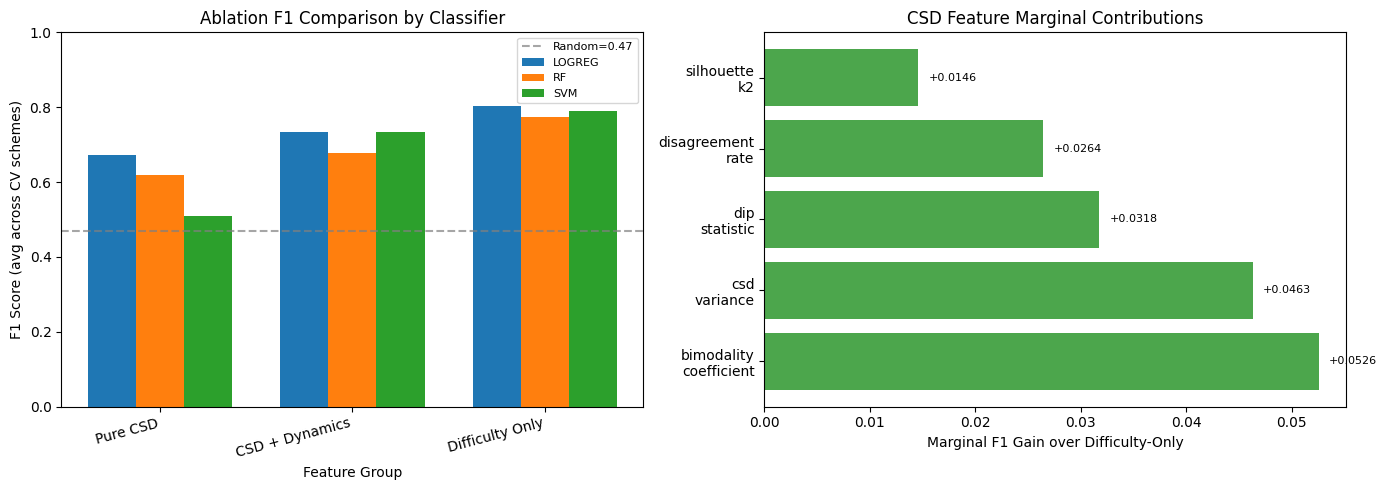

Figure saved to ablation_results.png

=== Ablation Results Table ===
Ablation                       Classifier CV      F1 Mean               95% CI
--------------------------------------------------------------------------------
abl_1_pure_csd                 logreg     lomo     0.6962       [0.584, 0.800]
abl_1_pure_csd                 logreg     lopo     0.6975       [0.582, 0.796]
abl_1_pure_csd                 logreg     loto     0.6199       [0.512, 0.725]
abl_1_pure_csd                 rf         lomo     0.6355       [0.513, 0.747]
abl_1_pure_csd                 rf         lopo     0.6671       [0.553, 0.769]
abl_1_pure_csd                 rf         loto     0.5562       [0.437, 0.658]
abl_1_pure_csd                 svm        lomo     0.5788       [0.449, 0.699]
abl_1_pure_csd                 svm        lopo     0.6151       [0.487, 0.724]
abl_1_pure_csd                 svm        loto     0.3308       [0.197, 0.457]
abl_2_csd_dynamics             logreg     lomo     0.7613   

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: F1 comparison across ablations (grouped bar chart) ──────────────
ax = axes[0]
abl_names = ["ablation_1_pure_csd", "ablation_2_csd_dynamics", "ablation_3_difficulty_only"]
abl_labels = ["Pure CSD", "CSD + Dynamics", "Difficulty Only"]
bar_width = 0.25

for i, clf in enumerate(CLASSIFIERS):
    f1_means = []
    f1_los = []
    f1_his = []
    for abl_name in abl_names:
        # Average across CV schemes for this classifier
        vals = []
        for cv in CV_SCHEMES:
            key = f"{clf}_{cv}"
            res = ablation_results.get(abl_name, {}).get("results", {}).get(key, {})
            if "f1_mean" in res:
                vals.append(res["f1_mean"])
        mean_val = np.mean(vals) if vals else 0
        f1_means.append(mean_val)

    x = np.arange(len(abl_labels))
    ax.bar(x + i * bar_width, f1_means, bar_width, label=clf.upper())

ax.set_xlabel("Feature Group")
ax.set_ylabel("F1 Score (avg across CV schemes)")
ax.set_title("Ablation F1 Comparison by Classifier")
ax.set_xticks(np.arange(len(abl_labels)) + bar_width)
ax.set_xticklabels(abl_labels, rotation=15, ha="right")
ax.legend()
ax.axhline(y=near_proportion, color='gray', linestyle='--', alpha=0.7, label=f'Random={near_proportion:.2f}')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)

# ── Plot 2: Incremental CSD feature contributions ──────────────────────────
ax = axes[1]
if "ablation_4_incremental" in ablation_results:
    incr = ablation_results["ablation_4_incremental"]
    fwd = incr.get("forward_from_difficulty", {})
    additions = fwd.get("additions", [])
    if additions:
        features = [a["feature"].replace("_", "\n") for a in additions]
        gains = [a["marginal_gain"] for a in additions]
        colors = ['green' if g > 0 else 'red' for g in gains]
        bars = ax.barh(features, gains, color=colors, alpha=0.7)
        ax.set_xlabel("Marginal F1 Gain over Difficulty-Only")
        ax.set_title("CSD Feature Marginal Contributions")
        ax.axvline(x=0, color='black', linewidth=0.5)
        for bar, gain in zip(bars, gains):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{gain:+.4f}', va='center', fontsize=8)
else:
    ax.text(0.5, 0.5, "Ablation 4 not run", ha='center', va='center', transform=ax.transAxes)
    ax.set_title("CSD Feature Marginal Contributions")

plt.tight_layout()
plt.savefig("ablation_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure saved to ablation_results.png")

# ── Print results table ─────────────────────────────────────────────────────
print("\n=== Ablation Results Table ===")
print(f"{'Ablation':<30} {'Classifier':<10} {'CV':<6} {'F1 Mean':>8} {'95% CI':>20}")
print("-" * 80)
for abl_name in abl_names:
    abl = ablation_results.get(abl_name, {})
    for key, val in sorted(abl.get("results", {}).items()):
        clf, cv = key.split("_", 1)
        ci = f"[{val['f1_ci_lo']:.3f}, {val['f1_ci_hi']:.3f}]"
        short_name = abl_name.replace("ablation_", "abl_")
        print(f"{short_name:<30} {clf:<10} {cv:<6} {val['f1_mean']:>8.4f} {ci:>20}")

print(f"\n=== Scientific Verdict ===")
print(summary_metrics["scientific_verdict"])